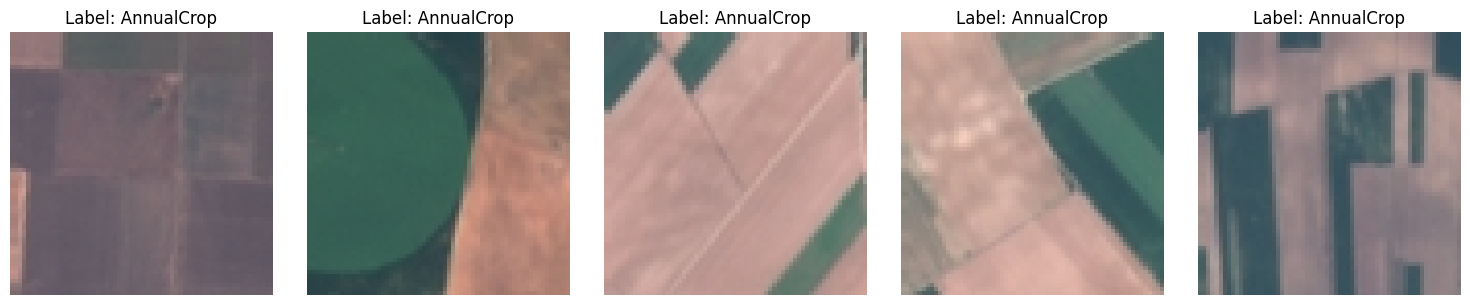

In [6]:
from torchvision.datasets import EuroSAT
import matplotlib.pyplot as plt
from torchvision import transforms

dataset = EuroSAT(root="../data", download=False, transform=transforms.ToTensor())

# Show 5 sample images
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    image, label = dataset[i]
    axs[i].imshow(image.permute(1, 2, 0))  # Convert from CxHxW to HxWxC
    axs[i].set_title(f"Label: {dataset.classes[label]}")
    axs[i].axis('off')
plt.tight_layout()
plt.show()


In [7]:
import torch
from torchvision.datasets import EuroSAT
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# Define transforms (add data augmentation here if you want)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load the full dataset
dataset = EuroSAT(root="../data", download=False, transform=transform)

# Split into train and validation (80/20 split)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")


Train samples: 21600, Validation samples: 5400


In [9]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Replace the final fully connected layer to match EuroSAT classes (10)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)  # EuroSAT has 10 classes

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

print(model)


cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=Tru

/home/tony/Documents/eurosat_classification/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tony/Documents/eurosat_classification/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
import torch.optim as optim
import torch.nn as nn

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [11]:
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


Epoch 1/10:
  Train Loss: 0.3917 | Train Acc: 0.8787
  Val Loss:   0.5472 | Val Acc:   0.8446
Epoch 2/10:
  Train Loss: 0.2277 | Train Acc: 0.9294
  Val Loss:   0.2911 | Val Acc:   0.9007
Epoch 3/10:
  Train Loss: 0.1644 | Train Acc: 0.9465
  Val Loss:   0.7547 | Val Acc:   0.7994
Epoch 4/10:
  Train Loss: 0.1445 | Train Acc: 0.9523
  Val Loss:   0.2478 | Val Acc:   0.9230
Epoch 5/10:
  Train Loss: 0.1107 | Train Acc: 0.9629
  Val Loss:   0.2048 | Val Acc:   0.9311
Epoch 6/10:
  Train Loss: 0.1011 | Train Acc: 0.9671
  Val Loss:   0.2294 | Val Acc:   0.9331
Epoch 7/10:
  Train Loss: 0.0939 | Train Acc: 0.9693
  Val Loss:   0.4198 | Val Acc:   0.8728
Epoch 8/10:
  Train Loss: 0.0773 | Train Acc: 0.9749
  Val Loss:   0.2122 | Val Acc:   0.9381
Epoch 9/10:
  Train Loss: 0.0757 | Train Acc: 0.9749
  Val Loss:   0.3056 | Val Acc:   0.9150
Epoch 10/10:
  Train Loss: 0.0651 | Train Acc: 0.9802
  Val Loss:   0.2608 | Val Acc:   0.9317
